# GymTEC — Análisis Exploratorio de Datos (EDA)
Dataset: Horario de clases
### Integrantes:
- Epiquien Rodas, Bihonda
- Villarreal Falcon, Mishelle
- Villón Zárate, Fátima

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


librerías:

In [54]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Carga de datos

Rutas archivos:

In [55]:
horarios_path = "/content/drive/MyDrive/2026-1/DPD - GYMTEC/horarios_clases.xlsx"
logs_gym_path = "/content/drive/MyDrive/2026-1/DPD - GYMTEC/logs_gym.xlsx"

In [56]:
horariosdf = pd.read_excel(horarios_path)

Inspección general del dataset

In [57]:
# Dimensiones del dataset crudo
print(f"Shape del dataset: {horariosdf.shape[0]} filas x {horariosdf.shape[1]} columnas")
print()

# Tipos de datos
print("=== Tipos de datos ===")
print(horariosdf.dtypes)
print()

# Primeras filas
print("=== Primeras 5 filas ===")
display(horariosdf.head())
print()

# Valores nulos por columna
print("=== Valores nulos por columna ===")
nulos = horariosdf.isna().sum()
print(nulos)
print(f"\nTotal de valores nulos: {nulos.sum()}")
print()

# Estadisticas descriptivas de columnas numericas
print("=== Estadísticas descriptivas ===")
display(horariosdf.describe())

Shape del dataset: 1811 filas x 12 columnas

=== Tipos de datos ===
Código Curso    object
Curso           object
Sección          int64
Sesión Grupo    object
Modalidad       object
Horario         object
Frecuencia      object
Ubicación       object
Vacantes         int64
Matriculados     int64
Docente         object
Correo          object
dtype: object

=== Primeras 5 filas ===


,Código Curso,Curso,Sección,Sesión Grupo,Modalidad,Horario,Frecuencia,Ubicación,Vacantes,Matriculados,Docente,Correo
0,CS5393,Algoritmos Avanzados y Complejidad,1,TEORÍA 1,Presencial,Mar. 15:00 - 17:00,Semana General,UTEC-BA A401,15,3,"Gutierrez Alva, Juan Gabriel",jgutierreza@utec.edu.pe
1,CS5393,Algoritmos Avanzados y Complejidad,1,TEORÍA 1,Presencial,Vie. 13:00 - 15:00,Semana General,UTEC-BA A501,15,3,"Gutierrez Alva, Juan Gabriel",jgutierreza@utec.edu.pe
2,CS2023,Algoritmos y Estructuras de Datos,2,TEORÍA 2,Presencial,Lun. 18:00 - 20:00,Semana General,UTEC-BA A804,45,28,"Sanchez Enriquez, Heider Ysaias",hsanchez@utec.edu.pe
3,CS2023,Algoritmos y Estructuras de Datos,2,LABORATORIO 21,Presencial,Mar. 20:00 - 22:00,Semana General,UTEC-BA M401,45,28,"Sanchez Enriquez, Heider Ysaias",hsanchez@utec.edu.pe
4,CS2023,Algoritmos y Estructuras de Datos,2,LABORATORIO 21,Presencial,Vie. 18:00 - 20:00,Semana General,UTEC-BA M1001,45,28,"Sanchez Enriquez, Heider Ysaias",hsanchez@utec.edu.pe



=== Valores nulos por columna ===
Código Curso     0
Curso            0
Sección          0
Sesión Grupo     0
Modalidad        0
Horario          0
Frecuencia       0
Ubicación        0
Vacantes         0
Matriculados     0
Docente         20
Correo          20
dtype: int64

Total de valores nulos: 40

=== Estadísticas descriptivas ===


,Sección,Vacantes,Matriculados
count,1811.000000,1811.000000,1811.000000
mean,2.441193,32.770293,26.848150
std,3.056420,31.718657,30.731211
min,1.000000,0.000000,0.000000
25%,1.000000,20.000000,11.000000
50%,1.000000,28.000000,22.000000
75%,2.000000,45.000000,37.000000
max,26.000000,300.000000,300.000000


# 2. Limpieza

## 2.1. Tabla horarios

In [58]:
# Reemplazar espacios en blanco por null
horariosdf = horariosdf.replace(r'^\s*$', np.nan, regex=True)

In [59]:
# Diccionario de facultades
facultades = {
    "CS": "Computación", "CY": "Computación", "DS": "Computación", "IS": "Computación",
    "CC": "Ciencias Generales",
    "GE": "Gestión", "GH": "Gestión", "GI": "Gestión",
    "HH": "Humanidades",
    "AM": "Ingeniería", "BI": "Ingeniería", "CI": "Ingeniería", "EL": "Ingeniería",
    "EN": "Ingeniería", "IN": "Ingeniería", "IQ": "Ingeniería", "ME": "Ingeniería",
    "MT": "Ingeniería", "PO": "Ingeniería", "QI": "Ingeniería",
    "BA": "Negocios", "AD": "Negocios",
    "PI": "Proyectos", "PR": "Proyectos"
}

# Diccionario de días
dias_map = {
    "Mar": "Martes",
    "Vie": "Viernes",
    "Lun": "Lunes",
    "Mie": "Miércoles",
    "Jue": "Jueves",
    "Sab": "Sábado"
}

# Nombres de columnas originales
col_curso = "Código Curso"
col_nombre = "Curso"
col_horario = "Horario"
col_seccion = "Sección"
col_modalidad = "Modalidad"
col_matriculados = "Matriculados"


In [60]:
# Limpieza
horariosdf[col_curso] = horariosdf[col_curso].astype(str).str.strip()

horariosdf["facultad"] = horariosdf[col_curso].str[:2].map(facultades)

horariosdf["dia_abrev"] = horariosdf[col_horario].astype(str).str[:3]
horariosdf["dia"] = horariosdf["dia_abrev"].map(dias_map)

horariosdf["hora_inicio"] = horariosdf[col_horario].astype(str).str[5:10]
horariosdf["hora_fin"] = horariosdf[col_horario].astype(str).str[-5:]

In [61]:
horarios_limpio = horariosdf[
    [
        "facultad",
        col_curso,
        col_nombre,
        col_seccion,
        col_modalidad,
        "dia",
        "hora_inicio",
        "hora_fin",
        col_matriculados
    ]
].copy()

In [62]:
horarios_limpio.columns = [
    "facultad",
    "cod_curso",
    "nombre_curso",
    "seccion",
    "modalidad",
    "dia",
    "hora_inicio",
    "hora_fin",
    "matriculados"
]

In [63]:
horarios_limpio.head()

,facultad,cod_curso,nombre_curso,seccion,modalidad,dia,hora_inicio,hora_fin,matriculados
0,Computación,CS5393,Algoritmos Avanzados y Complejidad,1,Presencial,Martes,15:00,17:00,3
1,Computación,CS5393,Algoritmos Avanzados y Complejidad,1,Presencial,Viernes,13:00,15:00,3
2,Computación,CS2023,Algoritmos y Estructuras de Datos,2,Presencial,Lunes,18:00,20:00,28
3,Computación,CS2023,Algoritmos y Estructuras de Datos,2,Presencial,Martes,20:00,22:00,28
4,Computación,CS2023,Algoritmos y Estructuras de Datos,2,Presencial,Viernes,18:00,20:00,28


In [64]:
horarios_limpio["matriculados"].value_counts().sort_index()

,count
matriculados,
0,20
1,21
2,21
3,15
4,37
...,...
289,3
290,1
294,1


In [65]:
horarios_limpio[horarios_limpio["matriculados"] == 0]

,facultad,cod_curso,nombre_curso,seccion,modalidad,dia,hora_inicio,hora_fin,matriculados
280,Gestión,GE4466,Construcción de compiladores,1,Presencial,Lunes,10:00,13:00,0
281,Gestión,GE4466,Construcción de compiladores,1,Presencial,Martes,10:00,13:00,0
282,Gestión,GE4466,Construcción de compiladores,1,Presencial,Miércoles,10:00,13:00,0
283,Gestión,GE4466,Construcción de compiladores,1,Presencial,Jueves,10:00,13:00,0
284,Gestión,GE4466,Construcción de compiladores,1,Presencial,Viernes,10:00,13:00,0
759,Gestión,GE4446,Innovación e iniciativa empresarial en tecnolo...,1,Presencial,Lunes,14:00,17:00,0
760,Gestión,GE4446,Innovación e iniciativa empresarial en tecnolo...,1,Presencial,Martes,14:00,17:00,0
761,Gestión,GE4446,Innovación e iniciativa empresarial en tecnolo...,1,Presencial,Miércoles,14:00,17:00,0
762,Gestión,GE4446,Innovación e iniciativa empresarial en tecnolo...,1,Presencial,Jueves,14:00,17:00,0
763,Gestión,GE4446,Innovación e iniciativa empresarial en tecnolo...,1,Presencial,Viernes,14:00,17:00,0


In [66]:
cursos_cero_count = (
    horarios_limpio[horarios_limpio["matriculados"] == 0]
    .groupby("nombre_curso")
    .size()
    .sort_values(ascending=False)
)

cursos_cero_count

,0
nombre_curso,
Construcción de compiladores,5
Innovación e iniciativa empresarial en tecnologías de energía limpia,5
Liderazgo,5
"Transformación digital: cómo el uso de datos, agilidad y tecnología está dando forma al futuro de nuestros negocios",5


In [67]:
horarios_limpio = horarios_limpio[horarios_limpio["matriculados"] > 0].copy()

# 3. EDA

Valores Nulos:
- No se presentan valores nulos

In [68]:
horarios_limpio.isna().sum()

,0
facultad,0
cod_curso,0
nombre_curso,0
seccion,0
modalidad,0
dia,0
hora_inicio,0
hora_fin,0
matriculados,0


## Análisis de Outliers

### 1. Outliers por tamaño de sección — IQR contextual por facultad
- Qué busca: Secciones cuya matrícula es atípica dentro del propio departamento. Sin embargo, este tipo de outliers suelen ser las secciones que tienen clases en Aula Magna o Auditorio.

- Por qué importa para GymTEC: Estas secciones son las que "rompen" el patrón promedio del campus. Son las clases que, al terminar, vacían el auditorio entero hacia las áreas comunes — incluyendo el gym. Identificarlas nos permite anticipar oleadas.

- Por qué boxplot horizontal con outliers resaltados (y no histograma): El histograma global nos oculta la heterogeneidad entre facultades. El boxplot horizontal por facultad ordenado por mediana te muestra simultáneamente:
    - el tamaño típico de cada facultad
    - su dispersión
    - qué tan lejos están los outliers de su propio contexto

Resaltar los puntos outlier en rojo los hace inmediatamente accionables.

/tmp/ipykernel_9356/3749263584.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('facultad', group_keys=False).apply(detectar_outliers_iqr)


Outliers de tamaño por facultad:

                    n_secciones  mediana  n_outliers  pct_outliers
facultad                                                          
Ciencias Generales          202     44.0          17           8.4
Proyectos                    98     21.5           5           5.1
Gestión                      66     25.0           3           4.5
Humanidades                 135     41.0           3           2.2
Computación                 378     30.0           8           2.1
Ingeniería                  806     16.0          11           1.4
Negocios                    106     15.0           0           0.0


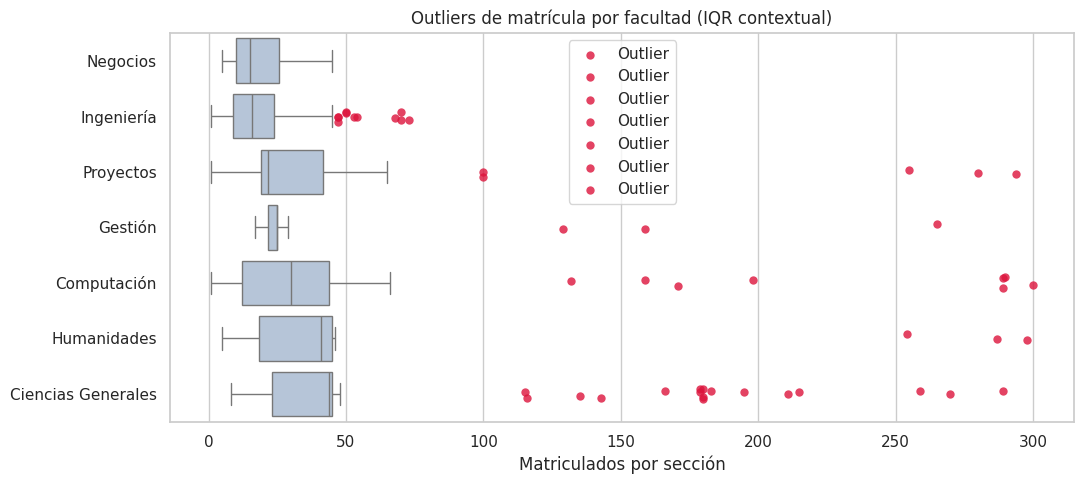

In [69]:
sns.set_theme(style="whitegrid", context="notebook")

df = horarios_limpio.copy()

# Detección IQR por facultad
def detectar_outliers_iqr(grupo):
    q1, q3 = grupo['matriculados'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    grupo['es_outlier_tam'] = grupo['matriculados'] > lim_sup
    grupo['lim_sup_facultad'] = lim_sup
    return grupo

df = df.groupby('facultad', group_keys=False).apply(detectar_outliers_iqr)

# Resumen
resumen = (df.groupby('facultad')
           .agg(n_secciones=('matriculados', 'size'),
                mediana=('matriculados', 'median'),
                n_outliers=('es_outlier_tam', 'sum'),
                pct_outliers=('es_outlier_tam', lambda x: round(x.mean()*100, 1)))
           .sort_values('pct_outliers', ascending=False))
print("Outliers de tamaño por facultad:\n")
print(resumen)

# Visualización
orden = df.groupby('facultad')['matriculados'].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, max(5, len(orden)*0.4)))
sns.boxplot(data=df, y='facultad', x='matriculados', order=orden,
            color='lightsteelblue', fliersize=0, ax=ax)
sns.stripplot(data=df[df['es_outlier_tam']], y='facultad', x='matriculados',
              order=orden, color='crimson', size=6, alpha=0.8,
              label='Outlier', ax=ax)
ax.set_title('Outliers de matrícula por facultad (IQR contextual)')
ax.set_xlabel('Matriculados por sección')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 2. Outliers de horarios — clases en bloques inusuales
- Qué busca:
  - Clases programadas en horarios que se desvían del patrón estándar (muy tempranas, muy tardías, o en días poco comunes como sábado).
- Por qué importa:
  - Estas clases generan micro-picos predecibles fuera de las horas normales del campus
  - Un sábado a las 8am con 200 alumnos = oportunidad perdida si tu producto solo modela L-V
  - Para GymTEC, son justamente las ventanas no obvias que marcan diferencia frente a una recomendación basada en "horario de oficina"
- Por qué countplot apilado por día/hora (no scatter):
  - Las dos variables son discretas (día, hora-bloque) y lo que importa es la frecuencia, no la magnitud individual.
  - El countplot nos muestra dónde la programación es densa vs. dispersa
  - Las celdas con conteo bajo son los outliers de horario — visualmente identificables como "huecos" en la grilla

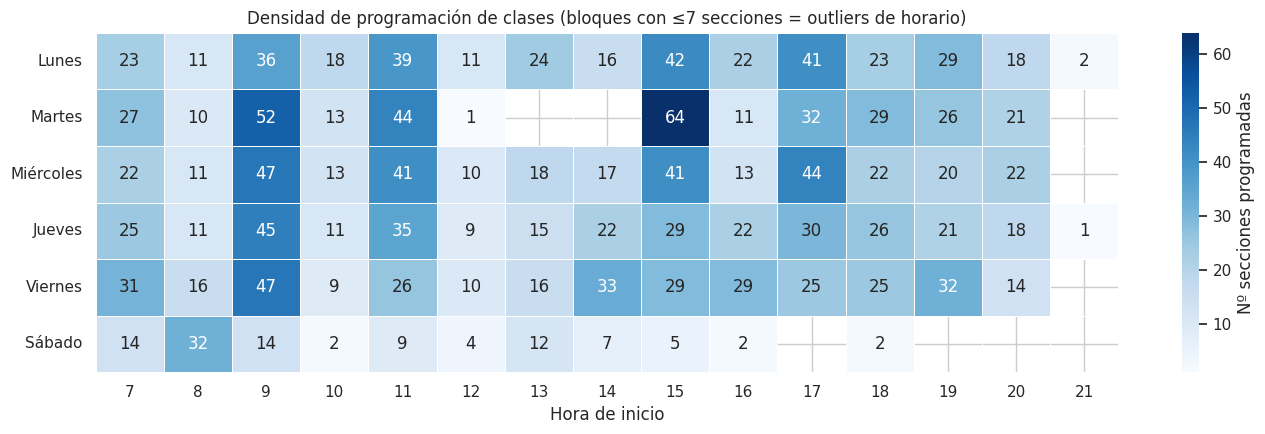


Bloques de horario atípicos (poca programación pero existen clases):
       dia  hora_int  n_secciones  es_outlier_horario
14  Jueves        21            1                True
35  Martes        12            1                True
29   Lunes        21            2                True
59  Sábado        10            2                True
65  Sábado        16            2                True
66  Sábado        18            2                True
61  Sábado        12            4                True
64  Sábado        15            5                True
63  Sábado        14            7                True


In [70]:
df['hora_int'] = pd.to_datetime(df['hora_inicio'], format='%H:%M', errors='coerce').dt.hour

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dias_presentes = [d for d in orden_dias if d in df['dia'].unique()]

# Conteo de secciones por bloque día-hora
freq = (df.groupby(['dia', 'hora_int']).size()
        .reset_index(name='n_secciones'))

# Marcar como outlier de horario si el bloque tiene < percentil 10 de secciones
umbral = freq['n_secciones'].quantile(0.10)
freq['es_outlier_horario'] = freq['n_secciones'] <= umbral

pivot_freq = freq.pivot(index='dia', columns='hora_int', values='n_secciones').reindex(dias_presentes)

plt.figure(figsize=(14, 4.5))
sns.heatmap(pivot_freq, cmap='Blues', annot=True, fmt='.0f',
            cbar_kws={'label': 'Nº secciones programadas'},
            linewidths=0.5, linecolor='white')
plt.title(f'Densidad de programación de clases (bloques con ≤{int(umbral)} secciones = outliers de horario)')
plt.xlabel('Hora de inicio')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Listar outliers de horario
print("\nBloques de horario atípicos (poca programación pero existen clases):")
print(freq[freq['es_outlier_horario']].sort_values('n_secciones'))

### 3. Outliers de densidad — bloques día-hora anómalamente saturados
- Qué busca:
  - Combinaciones día-hora donde la suma de matriculados se dispara respecto a la media del campus
  - Esto integra los outliers anteriores en una sola métrica accionable

- Por qué importa:
  - Este es el output más directo para GymTEC
  - Es literalmente "dónde no ir al gym"
  - Mientras los anteriores nos dan los datos de (tamaño, horario, duración), este nos daría un mapa de saturación con outliers marcados
- Por qué heatmap de z-scores con anotación selectiva (no heatmap absoluto):
  - Trabajar con z-scores normaliza la escala y hace comparables bloques de mañana vs. tarde
  - Anotar solo los outliers (|z| > 1.5) en lugar de todas las celdas reduce ruido visual y dirige la atención exclusivamente a los puntos accionables

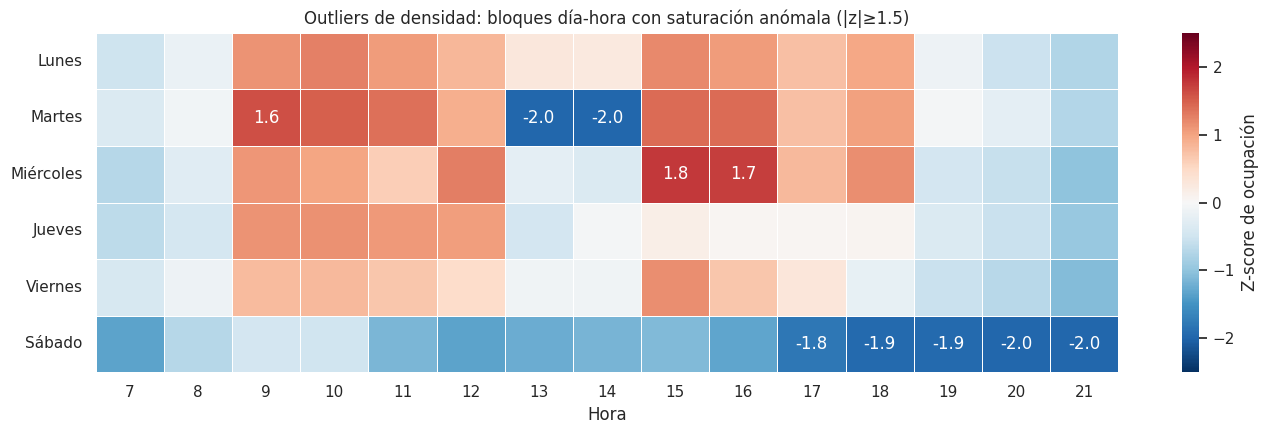

In [71]:
# Expandir cada clase a las horas que ocupa
def expandir_horas(row):
    h_ini = int(str(row['hora_inicio']).split(':')[0])
    h_fin = int(str(row['hora_fin']).split(':')[0])
    return list(range(h_ini, h_fin)) if h_fin > h_ini else [h_ini]

df_exp = df.assign(hora=df.apply(expandir_horas, axis=1)).explode('hora')
df_exp['hora'] = df_exp['hora'].astype(int)

# Filtro presencial si aplica
if 'modalidad' in df_exp.columns:
    df_exp_p = df_exp[df_exp['modalidad'].str.lower().str.contains('presencial', na=False)]
else:
    df_exp_p = df_exp

ocupacion = (df_exp_p.groupby(['dia', 'hora'])['matriculados'].sum()
             .unstack(fill_value=0).reindex(dias_presentes))

# Z-score sobre toda la matriz
z = (ocupacion - ocupacion.values.mean()) / ocupacion.values.std()

# Anotar solo outliers
annot = z.copy().astype(object)
annot[z.abs() < 1.5] = ''
annot[z.abs() >= 1.5] = z[z.abs() >= 1.5].round(1).astype(str)

plt.figure(figsize=(14, 4.5))
sns.heatmap(z, cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
            annot=annot, fmt='', linewidths=0.5,
            cbar_kws={'label': 'Z-score de ocupación'})
plt.title('Outliers de densidad: bloques día-hora con saturación anómala (|z|≥1.5)')
plt.xlabel('Hora')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4. Outliers multivariados — combinación tamaño × duración
- Qué busca:
  - Clases que son outliers no en una sola dimensión sino en la combinación de varias
  - Una clase de 3h con 150 alumnos no es atípica en duración ni en tamaño por separado, pero el combinado sí lo es — y es justo el caso más impactante para el gym
- Por qué importa:
  - El producto final de GymTEC necesitará un score compuesto de "impacto en el gym"
  - Las clases que disparan ese score son justamente las que combinan dimensiones extremas
- Por qué scatter con isolation forest o IQR multivariado (no scatter simple):
  - Un scatter plano te muestra la nube, pero los outliers multivariados son no-obvios visualmente — pueden estar en el "interior" de cada eje pero en una zona poco poblada del plano
  - Codificar el flag de outlier por color sobre el scatter convierte la detección en algo legible. Uso IQR multivariado por simplicidad y reproducibilidad (sin dependencias extra).

/tmp/ipykernel_9356/3835260698.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('facultad', group_keys=False).apply(marcar_outlier_tam)


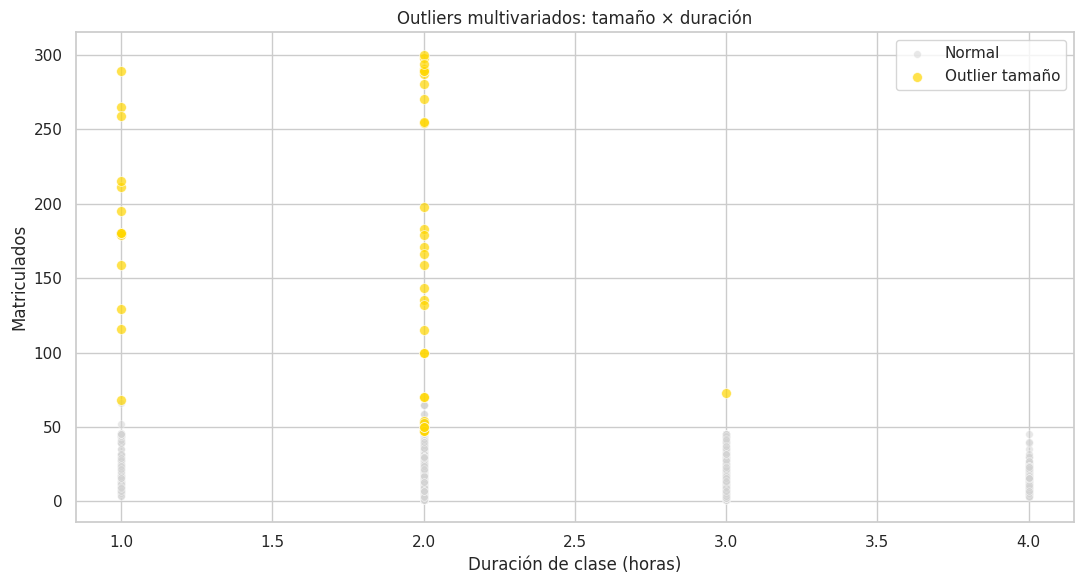


Umbral P95 de duración por curso: 4.0h
Total registros con outlier combinado: 0

Top clases de alto impacto (outlier en tamaño Y duración):
Empty DataFrame
Columns: [facultad, nombre_curso, cod_curso, dia, hora_inicio, duracion_h, matriculados]
Index: []


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df = horarios_limpio.copy()

# 1. Calcular duración por registro
df['hora_inicio_dt'] = pd.to_datetime(df['hora_inicio'], format='%H:%M', errors='coerce')
df['hora_fin_dt']    = pd.to_datetime(df['hora_fin'],    format='%H:%M', errors='coerce')
df['duracion_h']     = (df['hora_fin_dt'] - df['hora_inicio_dt']).dt.total_seconds() / 3600

# 2. Outlier de TAMAÑO (IQR contextual por facultad)
def marcar_outlier_tam(grupo):
    q1, q3 = grupo['matriculados'].quantile([0.25, 0.75])
    lim_sup = q3 + 1.5 * (q3 - q1)
    grupo['es_outlier_tam'] = grupo['matriculados'] > lim_sup
    return grupo

df = df.groupby('facultad', group_keys=False).apply(marcar_outlier_tam)

# 3. Outlier de DURACIÓN (a nivel curso, no registro — corrección que pediste antes)
duracion_por_curso = (df.groupby('cod_curso')['duracion_h']
                      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
                      .rename('duracion_curso'))

p95_curso = duracion_por_curso.quantile(0.95)
cursos_outlier = duracion_por_curso[duracion_por_curso > p95_curso].index

df['es_outlier_duracion'] = df['cod_curso'].isin(cursos_outlier)

# 4. Outlier multivariado
df['es_outlier_combo'] = df['es_outlier_tam'] & df['es_outlier_duracion']

# 5. Visualización
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df[~df['es_outlier_tam'] & ~df['es_outlier_duracion']],
                x='duracion_h', y='matriculados',
                color='lightgray', alpha=0.5, s=30, ax=ax, label='Normal')
sns.scatterplot(data=df[df['es_outlier_tam'] & ~df['es_outlier_duracion']],
                x='duracion_h', y='matriculados',
                color='gold', alpha=0.7, s=50, ax=ax, label='Outlier tamaño')
sns.scatterplot(data=df[df['es_outlier_duracion'] & ~df['es_outlier_tam']],
                x='duracion_h', y='matriculados',
                color='orange', alpha=0.7, s=50, ax=ax, label='Outlier duración')
sns.scatterplot(data=df[df['es_outlier_combo']],
                x='duracion_h', y='matriculados',
                color='crimson', alpha=0.9, s=90, ax=ax,
                label='Outlier combinado (alto impacto)', edgecolor='black')
ax.set_title('Outliers multivariados: tamaño × duración')
ax.set_xlabel('Duración de clase (horas)')
ax.set_ylabel('Matriculados')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Top clases de alto impacto
print(f"\nUmbral P95 de duración por curso: {p95_curso:.1f}h")
print(f"Total registros con outlier combinado: {df['es_outlier_combo'].sum()}\n")

print("Top clases de alto impacto (outlier en tamaño Y duración):")
cols = ['facultad', 'nombre_curso', 'cod_curso', 'dia', 'hora_inicio',
        'duracion_h', 'matriculados']
print(df[df['es_outlier_combo']][cols]
      .sort_values('matriculados', ascending=False)
      .head(10)
      .to_string(index=False))

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", context="notebook")

df = horarios_limpio.copy()
df['hora_inicio_dt'] = pd.to_datetime(df['hora_inicio'], format='%H:%M', errors='coerce')
df['hora_fin_dt']    = pd.to_datetime(df['hora_fin'],    format='%H:%M', errors='coerce')
df['duracion_h']     = (df['hora_fin_dt'] - df['hora_inicio_dt']).dt.total_seconds() / 3600
df['clase_id']       = df['cod_curso'].astype(str) + '_' + df['seccion'].astype(str)

# Filtro presencial (los virtuales no retienen físicamente)
if 'modalidad' in df.columns:
    df = df[df['modalidad'].str.lower().str.contains('presencial', na=False)].copy()

In [74]:
# Agregar a nivel SECCIÓN (cada sección es un grupo único de estudiantes)
secciones = (df.groupby(['cod_curso', 'seccion', 'nombre_curso', 'facultad'])
             .agg(matriculados=('matriculados', 'first'),
                  duracion_h=('duracion_h', 'mean'))
             .reset_index())

# Métrica de retención: estudiante-hora (alumnos × duración del bloque)
secciones['retencion'] = secciones['matriculados'] * secciones['duracion_h']

# Clustering sobre tamaño × duración (escalado para que pesen igual)
X = secciones[['matriculados', 'duracion_h']].values
X_scaled = StandardScaler().fit_transform(X)

# K=4 clusters para tipologías interpretables
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
secciones['cluster'] = kmeans.fit_predict(X_scaled)

# Etiquetar clusters por su perfil promedio (alta/baja retención)
perfil_clusters = (secciones.groupby('cluster')
                   .agg(matric_prom=('matriculados', 'mean'),
                        dur_prom=('duracion_h', 'mean'),
                        n_secciones=('seccion', 'count'),
                        retencion_prom=('retencion', 'mean'))
                   .sort_values('retencion_prom', ascending=False))

# Asignar nombres semánticos según ranking de retención
nombres_orden = ['🔴 Alta retención (megaclases largas)',
                 '🟠 Retención media-alta',
                 '🟡 Retención media-baja',
                 '🟢 Baja retención (clases pequeñas/cortas)']
mapa_nombres = dict(zip(perfil_clusters.index, nombres_orden))
secciones['cluster_nombre'] = secciones['cluster'].map(mapa_nombres)
perfil_clusters['nombre'] = nombres_orden

print("Perfil de los clusters:\n")
print(perfil_clusters.round(2))

Perfil de los clusters:

         matric_prom  dur_prom  n_secciones  retencion_prom  \
cluster                                                       
2             249.78      1.99           18          497.05   
3              23.90      3.57           68           84.65   
0              25.73      2.90          187           75.34   
1              26.58      1.93          321           50.76   

                                            nombre  
cluster                                             
2             🔴 Alta retención (megaclases largas)  
3                           🟠 Retención media-alta  
0                           🟡 Retención media-baja  
1        🟢 Baja retención (clases pequeñas/cortas)  


/tmp/ipykernel_9356/566124511.py:12: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/566124511.py:12: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/566124511.py:12: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/566124511.py:12: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-

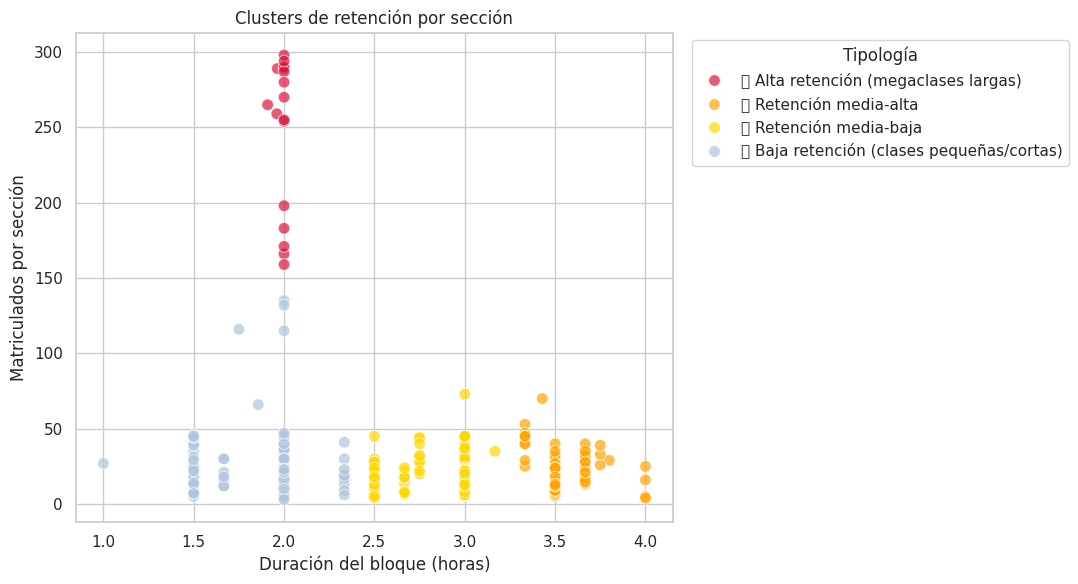

In [75]:
fig, ax = plt.subplots(figsize=(11, 6))
palette = {nombres_orden[0]: 'crimson', nombres_orden[1]: 'orange',
           nombres_orden[2]: 'gold', nombres_orden[3]: 'lightsteelblue'}

sns.scatterplot(data=secciones, x='duracion_h', y='matriculados',
                hue='cluster_nombre', hue_order=nombres_orden,
                palette=palette, alpha=0.7, s=70, ax=ax)
ax.set_title('Clusters de retención por sección')
ax.set_xlabel('Duración del bloque (horas)')
ax.set_ylabel('Matriculados por sección')
ax.legend(title='Tipología', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

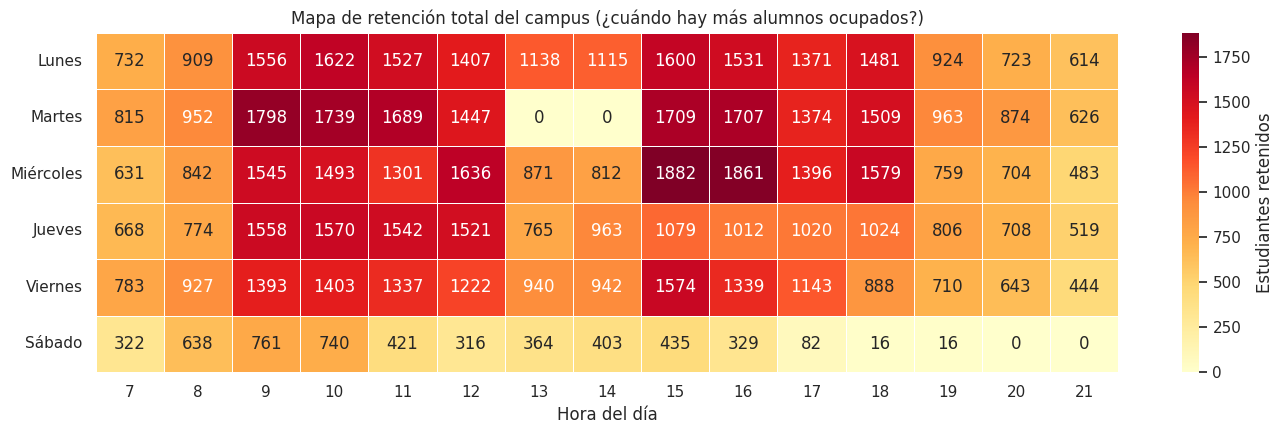

In [76]:
# Reincorporar info temporal a las secciones clusterizadas
df_clust = df.merge(secciones[['cod_curso', 'seccion', 'cluster_nombre', 'retencion']],
                    on=['cod_curso', 'seccion'], how='left')

# Expandir cada clase a sus horas activas
def expandir_horas(row):
    h_ini = int(str(row['hora_inicio']).split(':')[0])
    h_fin = int(str(row['hora_fin']).split(':')[0])
    return list(range(h_ini, h_fin)) if h_fin > h_ini else [h_ini]

df_clust['hora'] = df_clust.apply(expandir_horas, axis=1)
df_exp = df_clust.explode('hora')
df_exp['hora'] = df_exp['hora'].astype(int)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dias_pres = [d for d in orden_dias if d in df_exp['dia'].unique()]

# Mapa global: estudiante-hora total por (día, hora)
pivot_total = (df_exp.groupby(['dia', 'hora'])['matriculados'].sum()
               .unstack(fill_value=0).reindex(dias_pres))

plt.figure(figsize=(14, 4.5))
sns.heatmap(pivot_total, cmap='YlOrRd', annot=True, fmt='.0f',
            cbar_kws={'label': 'Estudiantes retenidos'},
            linewidths=0.5)
plt.title('Mapa de retención total del campus (¿cuándo hay más alumnos ocupados?)')
plt.xlabel('Hora del día')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Feature Engineering

## Set up inicial

Antes de construir las variables de disponibilidad académica, se definieron algunos parámetros y columnas base. Esta etapa permite que el análisis sea consistente, comparable y útil para los objetivos de GymTEC.

### `POBLACION_TOTAL`

La parametrización de `POBLACION_TOTAL` establece el denominador de referencia para construir métricas relativas de ocupación y disponibilidad. Esto permite transformar valores absolutos en proporciones comparables entre distintos ciclos académicos o tamaños de población estudiantil.

**Interpretación para Bienestar Estudiantil:**

- No es lo mismo tener 5,000 estudiantes ocupados en un campus de 8,000 que en uno de 20,000.
- Este indicador permite responder:

> ¿Qué porcentaje de estudiantes podría estar disponible para usar el gimnasio en este horario?

---

### `SLOT_MIN`

La granularidad temporal de 30 minutos responde a un equilibrio entre resolución analítica y densidad informativa. Una granularidad menor podría generar demasiada dispersión, mientras que una mayor podría ocultar transiciones importantes entre bloques académicos.

**Interpretación para Bienestar Estudiantil:**

- Permite distinguir momentos clave, por ejemplo:
  - estudiantes que salen a las 12:00
  - estudiantes que salen a las 12:30
- Esa diferencia puede marcar el inicio de un pico de demanda o una ventana ideal para recomendar asistencia al gimnasio.

---

### `duracion_h`

La variable `duracion_h` permite medir cuánto dura cada clase. Esta variable sirve como base para identificar clases largas, analizar posibles outliers y ponderar el impacto de cada clase sobre el flujo del campus.

**Interpretación para Bienestar Estudiantil:**

- Una clase de 4 horas no impacta igual que una clase de 1 hora.
- Las clases largas reducen la disponibilidad real de los estudiantes.
- Ayuda a responder:

> ¿Qué tan ocupados están los estudiantes más allá del número de clases programadas?

---

### `es_presencial`

La variable `es_presencial` funciona como un filtro físico clave. Su objetivo es diferenciar las clases que realmente implican presencia en campus frente a las clases virtuales.

**Interpretación para Bienestar Estudiantil:**

- Una hora con muchas clases virtuales no significa necesariamente que el campus esté lleno.
- Si no se considera esta variable, el modelo podría generar picos de demanda artificiales.
- Esto ayuda a evitar predicciones irreales sobre el uso del gimnasio.

---

### `clase_id`

La variable `clase_id` se construye combinando `cod_curso` y `seccion`. Esta columna representa la unidad mínima de análisis: una sección específica de un curso.

Su uso permite evitar errores de interpretación cuando una misma sección aparece en varios días de la semana.

**Interpretación para Bienestar Estudiantil:**

- Sin este identificador, podríamos contar varias veces al mismo grupo de estudiantes.
- Esto podría llevar a sobrestimar la cantidad de estudiantes ocupados.
- Permite una medición más ordenada y realista del flujo académico.

---

## Valor estratégico para GymTEC

Este set up prepara la tabla de horarios para construir una base estructural de disponibilidad académica. A partir de estas variables será posible estimar, por franja horaria:

- cuántos estudiantes están en clase
- cuántos podrían estar libres
- qué horarios concentran mayor carga académica
- qué momentos podrían representar oportunidades para recomendar el uso del gimnasio

En términos del producto, esta etapa permite avanzar hacia la pregunta central de GymTEC:

> ¿Cuánta gente podría ir al gimnasio porque no está en clase?

In [77]:
POBLACION_TOTAL = 5000
SLOT_MIN = 30

df = horarios_limpio.copy()
df['hora_inicio_dt'] = pd.to_datetime(df['hora_inicio'], format='%H:%M', errors='coerce')
df['hora_fin_dt']    = pd.to_datetime(df['hora_fin'],    format='%H:%M', errors='coerce')
df['duracion_h']     = (df['hora_fin_dt'] - df['hora_inicio_dt']).dt.total_seconds() / 3600
df['es_presencial']  = df['modalidad'].str.lower().str.contains('presencial', na=False)

# CLAVE: identificador único de grupo de estudiantes
df['clase_id'] = df['cod_curso'].astype(str) + '_' + df['seccion'].astype(str)

## Expansión de horarios a intervalos temporales

Esta transformación modifica la unidad de observación del dataset, pasando de una estructura donde cada fila representa una sección programada, a una estructura donde cada fila representa una sección activa en un intervalo temporal específico

Este cambio responde a una necesidad estructural del modelo:
- GymTEC no busca analizar clases como entidades aisladas, sino modelar el estado del campus a lo largo del tiempo
- En particular, los requerimientos RF-01 (predicción de aforo) y RF-02 (recomendación de horarios) requieren estimaciones por franja horaria, lo cual hace indispensable esta transformación

### Importancia del ajuste con `pd.Timedelta(minutes=1)`

- Durante la expansión de los intervalos, se aplica un ajuste en el límite superior utilizando `pd.Timedelta(minutes=1)`. Este ajuste evita un error común en el modelado temporal
  - Por ejemplo, si una clase termina a las 12:00, no debería considerarse dentro del intervalo que inicia a las 12:00, ya que en ese momento los estudiantes ya han salido del aula
  - Sin este ajuste, se introduciría una sobreestimación sistemática de la ocupación en los puntos de transición entre bloques académicos.

### Impacto sobre el modelo

- Sin esta expansión, el modelo quedaría limitado a aprender patrones a nivel de curso o sección, sin capacidad de capturar dinámicas temporales
- La predicción de aforo requiere representar cómo evoluciona la disponibilidad de los estudiantes a lo largo del día, lo cual es estructuralmente imposible si la unidad de análisis se mantiene a nivel de clase

Esta transformación permite construir variables clave como:

- estudiantes ocupados por franja horaria  
- estudiantes potencialmente disponibles  
- intensidad de carga académica por momento del día  
- identificación de horas pico y horas valle  

En este sentido, la expansión funciona como el puente entre el dato académico y el dato temporal necesario para el modelado.

---

## Justificación desde Bienestar Estudiantil

- Desde la perspectiva de Bienestar Estudiantil, el valor de esta transformación radica en que permite traducir la estructura académica en una representación clara de la disponibilidad estudiantil a lo largo del día

Sin esta transformación, la información disponible se limita a horarios de clases individuales, lo cual no permite responder preguntas operativas como:

- ¿En qué momentos hay más estudiantes disponibles?
- ¿Cuándo es más probable que el gimnasio se llene?
- ¿En qué horarios conviene incentivar la asistencia?

Con la expansión temporal, es posible construir una visión agregada del campus por franja horaria, permitiendo identificar:

- momentos de alta carga académica (menor disponibilidad)
- ventanas de tiempo con mayor proporción de estudiantes libres
- posibles puntos de saturación del gimnasio
- oportunidades para redistribuir la demanda

En términos prácticos, esto permite pasar de una visión estática (horarios) a una visión dinámica del comportamiento potencial de los estudiantes.

---

## Valor estratégico para GymTEC

- Esta transformación no solo habilita el desarrollo técnico del modelo, sino que constituye un paso clave en la construcción del producto.

- La expansión temporal establece la base sobre la cual se construye todo el sistema de análisis y recomendación.

In [78]:
def expandir_a_slots(row, slot_min=SLOT_MIN):
    if pd.isna(row['hora_inicio_dt']) or pd.isna(row['hora_fin_dt']):
        return []
    slots = pd.date_range(start=row['hora_inicio_dt'],
                          end=row['hora_fin_dt'] - pd.Timedelta(minutes=1),
                          freq=f'{slot_min}min')
    return [s.strftime('%H:%M') for s in slots]

df['slots'] = df.apply(expandir_a_slots, axis=1)
df_exp = df.explode('slots').rename(columns={'slots': 'slot'})
df_exp = df_exp[df_exp['slot'].notna()].copy()

# Verificación: ¿una clase aparece más de una vez en el mismo (dia, slot)?
dup_check = df_exp.groupby(['dia', 'slot', 'clase_id']).size()
print(f"Duplicados por (dia, slot, clase_id): {(dup_check > 1).sum()}")
# Si esto es > 0, algo está mal en los datos originales

Duplicados por (dia, slot, clase_id): 654


## Control de duplicados en la expansión temporal

### Fundamento

- Esta operación constituye una salvaguarda crítica contra la inflación de métricas derivada de duplicaciones accidentales en los datos fuente

- En sistemas académicos institucionales, es común encontrar registros redundantes debido a modificaciones operativas, tales como cambios de aula, reasignación de docentes o ajustes administrativos

- La aplicación de una deduplicación basada en la combinación de variables `(dia, slot, clase_id)` garantiza que cada grupo de estudiantes sea contabilizado una única vez en cada intervalo temporal, independientemente del número de registros asociados en la fuente original

>En términos conceptuales, esta operación asegura que la unidad de análisis —**un grupo de estudiantes en un momento específico**— se mantenga consistente y no se vea afectada por artefactos del sistema de registro.

---

### Importancia práctica

Sin este control, una misma sección podría aparecer múltiples veces en el dataset expandido, generando un conteo duplicado de estudiantes en un mismo horario

Por ejemplo, si una sección de 40 estudiantes está duplicada en el sistema, el modelo interpretaría que hay 80 estudiantes ocupados en ese bloque, lo cual no refleja la realidad

---

### Impacto sobre el modelo

La presencia de duplicados no controlados introduce un sesgo sistemático al alza en las métricas de ocupación, tales como:

- estudiantes_ocupados  
- carga_academica  
- densidad del campus  

Este tipo de error es particularmente crítico porque suele ser invisible en etapas tempranas: las métricas pueden parecer coherentes, pero el modelo aprende patrones inflados

Como consecuencia:

- se sobreestima la ocupación del campus  
- se subestima la disponibilidad de estudiantes  
- se predicen niveles de aforo del gimnasio más altos de lo real  

En un entorno de producción, este tipo de desviación es difícil de detectar, ya que no genera errores explícitos, sino predicciones consistentemente sesgadas

La deduplicación actúa, por tanto, como un mecanismo de robustez fundamental en la construcción del dataset

---

### Justificación desde Bienestar Estudiantil

Desde la perspectiva de Bienestar Estudiantil, esta operación asegura que las métricas reflejen fielmente la realidad del campus.

Sin este control, podrían surgir interpretaciones erróneas como:

- “El campus está más lleno de lo que realmente está”
- “Hay menos estudiantes disponibles para usar el gimnasio”
- “El gimnasio debería estar más lleno en ciertos horarios”

Esto podría llevar a decisiones incorrectas, como:

- sobredimensionar la demanda del gimnasio  
- diseñar estrategias de intervención en horarios equivocados  
- generar recomendaciones poco efectivas para los estudiantes  

*Al garantizar que cada grupo de estudiantes se contabilice una sola vez, se preserva la integridad del análisis y se asegura que las decisiones se basen en una representación precisa de la dinámica académica*

---

### Valor estratégico para GymTEC

La incorporación de este control permite construir features confiables, evitando sesgos estructurales que afectarían directamente el desempeño del modelo.

Esto es especialmente importante para:

- RF-01 (predicción de aforo), donde pequeñas sobreestimaciones pueden escalar en errores significativos  
- RF-02 (recomendación de horarios), donde una mala estimación de disponibilidad impacta directamente la calidad de la recomendación  

En este sentido, la deduplicación no es solo una limpieza de datos, sino un componente clave para asegurar la calidad y confiabilidad del producto final.

In [79]:
# Cada (dia, slot, clase_id) debe contar UNA sola vez con sus matriculados
df_exp_unico = df_exp.drop_duplicates(subset=['dia', 'slot', 'clase_id']).copy()

# Outliers de tamaño a nivel sección (no a nivel registro expandido)
def marcar_outlier_tam(g):
    q1, q3 = g['matriculados'].quantile([0.25, 0.75])
    g['es_outlier_tam'] = g['matriculados'] > q3 + 1.5 * (q3 - q1)
    return g

# Aplicar sobre el dataset original a nivel sección
secciones = (df.drop_duplicates(subset=['clase_id'])
             [['clase_id', 'facultad', 'matriculados']])
secciones = secciones.groupby('facultad', group_keys=False).apply(marcar_outlier_tam)
df_exp_unico = df_exp_unico.merge(secciones[['clase_id', 'es_outlier_tam']],
                                   on='clase_id', how='left')

# Cursos largos a nivel curso (no sección)
dur_curso = df.groupby('cod_curso')['duracion_h'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
p95_dur = dur_curso.quantile(0.95)
cursos_largos = dur_curso[dur_curso > p95_dur].index
df_exp_unico['es_curso_largo'] = df_exp_unico['cod_curso'].isin(cursos_largos)

/tmp/ipykernel_9356/877010461.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  secciones = secciones.groupby('facultad', group_keys=False).apply(marcar_outlier_tam)


## Agregación principal por día y slot

### Fundamento

Esta operación consolida el dataset en su forma final de consumo para el modelo. Luego de expandir las clases por intervalos temporales y controlar duplicados, se agrupa la información por `(dia, slot)` para obtener una fila por cada estado del campus en una franja horaria específica.

Cada métrica agregada captura una dimensión distinta del campus y responde a una pregunta de negocio diferente:

- `estudiantes_ocupados`: ¿cuántos estudiantes están en clase?
- `estudiantes_presencial`: ¿cuántos estudiantes están físicamente en campus?
- `n_secciones_activas`: ¿cuántos grupos o espacios académicos están activos al mismo tiempo?
- `n_cursos_activos`: ¿cuánta diversidad académica existe en ese intervalo?
- `duracion_prom_clases`: ¿qué tan extensas son las clases activas en ese momento?

---

### Importancia de distinguir secciones y cursos

La diferencia entre `n_secciones_activas` y `n_cursos_activos` es metodológicamente relevante.

Por ejemplo, no es lo mismo tener:

- 5 secciones activas de un mismo curso
- 5 secciones activas de cursos distintos

Aunque ambos escenarios podrían tener una cantidad similar de estudiantes matriculados, representan dinámicas diferentes del campus.

El primer caso sugiere mayor concentración en una zona, facultad o edificio específico. El segundo caso sugiere una distribución más amplia de estudiantes y mayor flujo cruzado por el campus.

---

### Impacto sobre el modelo

Esta capa representa el dataset que posteriormente podrá consumir el modelo. Cada variable describe una dimensión interpretable del estado del campus.

Por ejemplo, un modelo como Random Forest, XGBoost o LightGBM podría aprender reglas del tipo:

> Cuando la carga académica es alta y la duración promedio de clases también es alta, es probable que exista una salida concentrada de estudiantes en el siguiente bloque horario.

Esto permite que el modelo identifique patrones operativos como:

- momentos de alta concentración académica
- horarios cercanos a salidas masivas de clase
- franjas con mayor disponibilidad potencial
- intervalos donde podría aumentar la demanda del gimnasio

---

### Justificación desde Bienestar Estudiantil

Desde la perspectiva de Bienestar Estudiantil, esta agregación permite transformar los horarios académicos en una lectura operativa del campus.

En lugar de revisar clases individuales, se obtiene una vista resumida por franja horaria que permite responder preguntas como:

- ¿En qué horarios hay más estudiantes ocupados?
- ¿Cuándo hay mayor presencia física en campus?
- ¿Qué momentos podrían generar mayor flujo hacia el gimnasio?
- ¿En qué horarios existen oportunidades para recomendar asistencia?

Esto facilita la toma de decisiones sobre gestión de aforo, comunicación con estudiantes y planificación de recursos del gimnasio.

---

### Valor estratégico para GymTEC

Esta agregación es una etapa clave porque convierte los datos académicos en features directamente utilizables para los objetivos del producto.

Para RF-01, permite construir variables explicativas para predecir el aforo esperado del gimnasio.

Para RF-02, permite identificar horarios potencialmente recomendables según disponibilidad, carga académica y dinámica del campus.

En conjunto, esta capa transforma la tabla de horarios en una representación estructurada del comportamiento potencial de los estudiantes frente al uso del gimnasio.

In [80]:
agg = df_exp_unico.groupby(['dia', 'slot']).agg(
    estudiantes_ocupados   = ('matriculados', 'sum'),
    estudiantes_presencial = ('matriculados',
                              lambda x: x[df_exp_unico.loc[x.index, 'es_presencial']].sum()),
    estudiantes_virtual    = ('matriculados',
                              lambda x: x[~df_exp_unico.loc[x.index, 'es_presencial']].sum()),
    n_secciones_activas    = ('clase_id', 'nunique'),     # secciones únicas
    n_cursos_activos       = ('cod_curso', 'nunique'),    # cursos únicos
    n_facultades_activas   = ('facultad', 'nunique'),
    duracion_prom_clases   = ('duracion_h', 'mean'),
    matric_seccion_max     = ('matriculados', 'max'),
    matric_seccion_prom    = ('matriculados', 'mean'),
    n_outliers_tamano      = ('es_outlier_tam', 'sum'),
    n_cursos_largos        = ('es_curso_largo', 'sum'),
).reset_index()

print(f"Dataset agregado: {agg.shape}")
agg.head()

Dataset agregado: (172, 13)


,dia,slot,estudiantes_ocupados,estudiantes_presencial,estudiantes_virtual,n_secciones_activas,n_cursos_activos,n_facultades_activas,duracion_prom_clases,matric_seccion_max,matric_seccion_prom,n_outliers_tamano,n_cursos_largos
0,Jueves,07:00,623,623,0,24,23,6,2.250000,45,25.958333,2,0
1,Jueves,07:30,623,623,0,24,23,6,2.250000,45,25.958333,2,0
2,Jueves,08:00,722,710,12,33,32,6,2.333333,45,21.878788,2,0
3,Jueves,08:30,722,710,12,33,32,6,2.333333,45,21.878788,2,0
4,Jueves,09:00,1357,1275,82,52,46,6,2.461538,45,26.096154,8,0


## Resumen de justificación del Feature Engineering aplicado

### 1. Features de disponibilidad

- Permiten responder la pregunta central de GymTEC: **cuántos estudiantes podrían ir al gimnasio porque no están en clase**.
- `ratio_libres` ayuda directamente a RF-02, porque identifica horarios con mayor disponibilidad potencial.
- `carga_academica` ayuda a RF-01, porque indica qué tan ocupado está el campus y permite anticipar posibles cambios futuros en el aforo.

---

### 2. Features de modalidad

- `ratio_virtual` evita sobreestimar la presencia física en campus.
- Permite diferenciar entre estudiantes ocupados en clases presenciales y estudiantes ocupados en clases virtuales.
- Esto es importante porque una clase virtual no genera el mismo flujo hacia el gimnasio que una clase presencial.

---

### 3. Features temporales

- La codificación cíclica (`hora_sin`, `hora_cos`, `dia_sin`, `dia_cos`) permite representar correctamente patrones repetitivos de horas y días.
- Evita que el modelo interprete el tiempo como una variable lineal, cuando en realidad los horarios y días tienen comportamiento cíclico.
- `es_hora_pico_academica` identifica momentos donde el campus tiene alta carga académica.

---

### 4. Features avanzadas

- `fragmentacion` permite distinguir si la actividad académica está distribuida en muchas clases cortas o pocas clases largas.
- `diversidad_facultades` ayuda a entender si el flujo estudiantil está concentrado en una facultad o distribuido en varias.
- `ratio_clases_outlier` identifica horarios dominados por clases atípicas, que podrían alterar el comportamiento normal del campus.

---

### 5. Lags y leads

- Estas variables capturan la dinámica temporal del campus, no solo su estado actual.
- `delta_carga` indica si la carga académica está aumentando o disminuyendo.
- `salida_inminente` permite anticipar posibles oleadas de estudiantes saliendo de clase, lo cual es clave para predecir aumentos futuros en el aforo del gimnasio.


In [81]:
# Disponibilidad
agg['estudiantes_libres'] = (POBLACION_TOTAL - agg['estudiantes_presencial']).clip(lower=0)
agg['ratio_libres']       = agg['estudiantes_libres'] / POBLACION_TOTAL
agg['carga_academica']    = agg['estudiantes_presencial'] / POBLACION_TOTAL

In [82]:
# Modalidad
total_mod = agg['estudiantes_presencial'] + agg['estudiantes_virtual']
agg['ratio_virtual'] = np.where(total_mod > 0, agg['estudiantes_virtual'] / total_mod, 0)

In [83]:
# Temporales
orden_dias = {'Lunes':0,'Martes':1,'Miércoles':2,'Jueves':3,
              'Viernes':4,'Sábado':5,'Domingo':6}
agg['dia_num']  = agg['dia'].map(orden_dias)
agg['hora_dec'] = agg['slot'].apply(lambda s: int(s.split(':')[0]) + int(s.split(':')[1])/60)
agg['es_finde'] = (agg['dia_num'] >= 5).astype(int)
agg['hora_sin'] = np.sin(2*np.pi*agg['hora_dec']/24)
agg['hora_cos'] = np.cos(2*np.pi*agg['hora_dec']/24)
agg['dia_sin']  = np.sin(2*np.pi*agg['dia_num']/7)
agg['dia_cos']  = np.cos(2*np.pi*agg['dia_num']/7)

umbral_pico = agg['carga_academica'].quantile(0.80)
agg['es_hora_pico_academica'] = (agg['carga_academica'] >= umbral_pico).astype(int)

In [84]:
# Avanzadas
agg['fragmentacion'] = agg['n_secciones_activas'] / agg['duracion_prom_clases'].replace(0, np.nan)
agg['fragmentacion'] = agg['fragmentacion'].fillna(0)
agg['diversidad_facultades'] = agg['n_facultades_activas'] / df['facultad'].nunique()
agg['ratio_clases_outlier']  = (agg['n_outliers_tamano'] /
                                agg['n_secciones_activas'].replace(0, np.nan)).fillna(0)

In [85]:
# Lags y leads
agg = agg.sort_values(['dia_num', 'hora_dec']).reset_index(drop=True)
agg['carga_t-1']        = agg.groupby('dia')['carga_academica'].shift(1).fillna(0)
agg['carga_t+1']        = agg.groupby('dia')['carga_academica'].shift(-1).fillna(0)
agg['delta_carga']      = agg['carga_academica'] - agg['carga_t-1']
agg['salida_inminente'] = (agg['carga_t+1'] < agg['carga_academica'] * 0.7).astype(int)

print(f"Total features: {agg.shape[1]}")
agg[['dia','slot','estudiantes_presencial','n_secciones_activas',
     'n_cursos_activos','carga_academica','ratio_libres']].head(10)

Total features: 32


,dia,slot,estudiantes_presencial,n_secciones_activas,n_cursos_activos,carga_academica,ratio_libres
0,Lunes,07:00,732,23,22,0.1464,0.8536
1,Lunes,07:30,732,23,22,0.1464,0.8536
2,Lunes,08:00,909,33,31,0.1818,0.8182
3,Lunes,08:30,909,33,31,0.1818,0.8182
4,Lunes,09:00,1437,48,45,0.2874,0.7126
5,Lunes,09:30,1437,48,45,0.2874,0.7126
6,Lunes,10:00,1503,50,46,0.3006,0.6994
7,Lunes,10:30,1503,50,46,0.3006,0.6994
8,Lunes,11:00,1460,57,48,0.2920,0.7080
9,Lunes,11:30,1460,57,48,0.2920,0.7080


# Preguntas de investigación


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Definición del horario operativo del gimnasio
HORARIO_GYM = {
    'Lunes':     (9.0, 18.0),
    'Martes':    (9.0, 18.0),
    'Miércoles': (9.0, 18.0),
    'Jueves':    (9.0, 18.0),
    'Viernes':   (9.0, 18.0),
    'Sábado':    (8.0, 13.0),
}

def en_horario_operativo(row):
    if row['dia'] not in HORARIO_GYM:
        return False
    h_ini, h_fin = HORARIO_GYM[row['dia']]
    return h_ini <= row['hora_dec'] < h_fin

agg_op = agg[agg.apply(en_horario_operativo, axis=1)].copy()

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']
dias_pres = [d for d in orden_dias if d in agg_op['dia'].unique()]

print(f"Slots totales en agg: {len(agg)}")
print(f"Slots dentro de horario operativo del gym: {len(agg_op)}")
print(f"Distribución por día:")
print(agg_op['dia'].value_counts().reindex(dias_pres))

Slots totales en agg: 172
Slots dentro de horario operativo del gym: 96
Distribución por día:
dia
Lunes        18
Martes       14
Miércoles    18
Jueves       18
Viernes      18
Sábado       10
Name: count, dtype: int64


## P1 — Comportamiento temporal de la demanda académica
Pregunta principal: ¿Cómo se distribuye el flujo de estudiantes en campus a lo largo de la semana y del día, y dónde están los valles de baja ocupación que representan oportunidades para ir al gimnasio?

- P1.1 ¿Qué bloques horarios concentran la mayor cantidad de estudiantes en clase (picos) y cuáles son los valles?
- P1.2 ¿Cómo varía la presión académica entre días de la semana? ¿Hay días "ligeros"?
- P1.3 ¿Existen transiciones críticas (cambios bruscos hora a hora) que indiquen movimientos masivos en el campus?

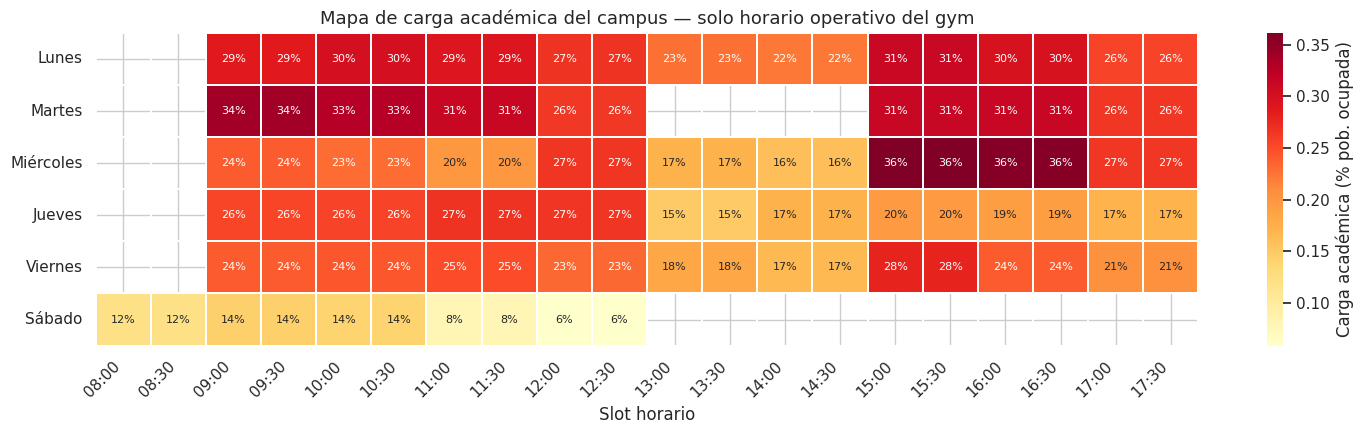

In [87]:
pivot = agg_op.pivot(index='dia', columns='slot', values='carga_academica').reindex(dias_pres)

plt.figure(figsize=(15, 4.5))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Carga académica (% pob. ocupada)'},
            linewidths=0.3, annot=True, fmt='.0%', annot_kws={'size': 8})
plt.title('Mapa de carga académica del campus — solo horario operativo del gym',
          fontsize=13)
plt.xlabel('Slot horario')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

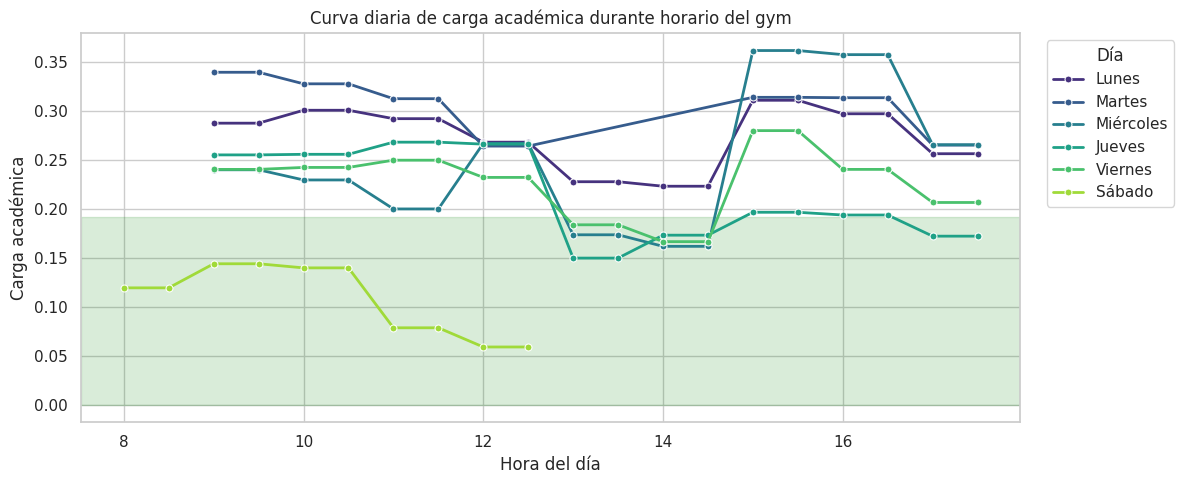

In [88]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=agg_op, x='hora_dec', y='carga_academica',
             hue='dia', hue_order=dias_pres,
             palette='viridis', linewidth=2, marker='o', markersize=5)
plt.title('Curva diaria de carga académica durante horario del gym')
plt.xlabel('Hora del día')
plt.ylabel('Carga académica')
plt.legend(title='Día', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhspan(0, agg_op['carga_academica'].quantile(0.25), alpha=0.15, color='green',
            label='Zona valle')
plt.tight_layout()
plt.show()

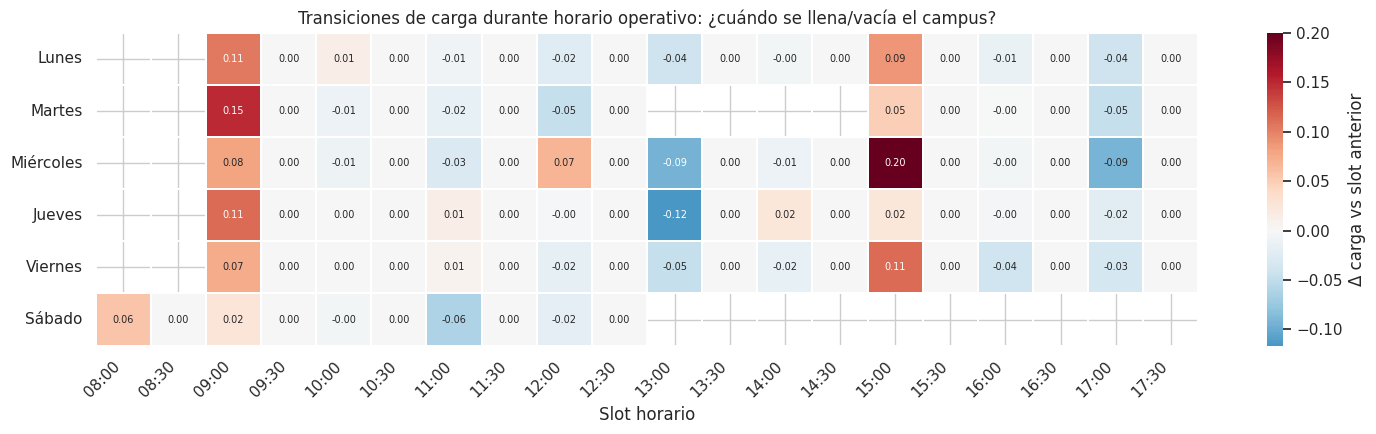

In [89]:
pivot_delta = agg_op.pivot(index='dia', columns='slot', values='delta_carga').reindex(dias_pres)

plt.figure(figsize=(15, 4.5))
sns.heatmap(pivot_delta, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Δ carga vs slot anterior'},
            linewidths=0.3, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Transiciones de carga durante horario operativo: ¿cuándo se llena/vacía el campus?')
plt.xlabel('Slot horario')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## P2 — ¿Cuándo conviene ir al gimnasio para encontrarlo con menor concurrencia, y cómo identificamos esos momentos de manera sistemática?

- ¿Cuáles son los horarios más recomendados y los que definitivamente debo evitar?
- ¿Cómo definimos objetivamente qué es 'zona verde' (óptima) y qué es 'zona roja' (a evitar)?

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Horario operativo del gym
HORARIO_GYM = {
    'Lunes':     (9.0, 18.0),
    'Martes':    (9.0, 18.0),
    'Miércoles': (9.0, 18.0),
    'Jueves':    (9.0, 18.0),
    'Viernes':   (9.0, 18.0),
    'Sábado':    (8.0, 13.0),
}

def en_horario_operativo(row):
    if row['dia'] not in HORARIO_GYM:
        return False
    h_ini, h_fin = HORARIO_GYM[row['dia']]
    return h_ini <= row['hora_dec'] < h_fin

agg_op = agg[agg.apply(en_horario_operativo, axis=1)].copy()

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']
dias_pres = [d for d in orden_dias if d in agg_op['dia'].unique()]

/tmp/ipykernel_9356/448902986.py:40: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/448902986.py:40: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


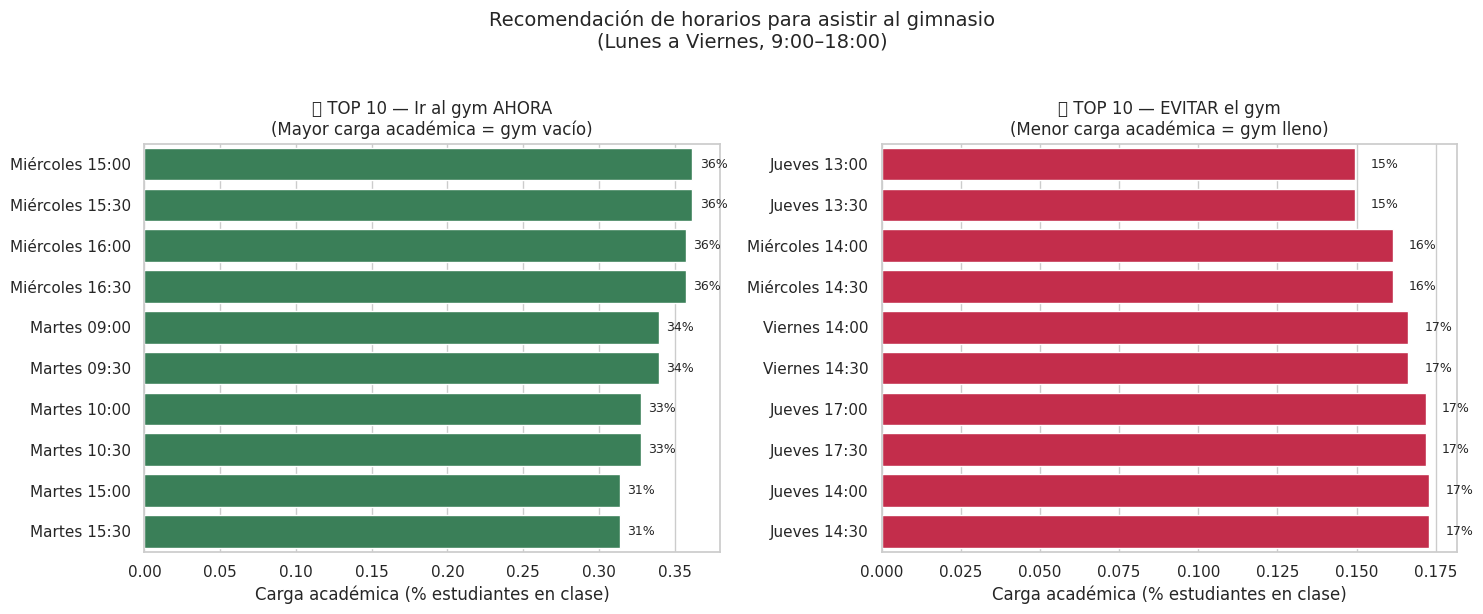

In [97]:
# Solo días laborales para comparabilidad
dias_laborales = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
agg_lv = agg_op[agg_op['dia'].isin(dias_laborales)].copy()

agg_ranked = agg_lv.copy()
agg_ranked['etiqueta'] = agg_ranked['dia'] + ' ' + agg_ranked['slot']

# 🟢 Mejores horarios = MAYOR carga académica (más gente atrapada en clase)
top_ir = agg_ranked.nlargest(10, 'carga_academica')[
    ['etiqueta', 'carga_academica', 'ratio_libres']]

# 🔴 Peores horarios = MENOR carga académica (mucha gente libre que podría llenar el gym)
top_evitar = agg_ranked.nsmallest(10, 'carga_academica')[
    ['etiqueta', 'carga_academica', 'ratio_libres']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Verde: alta carga académica = gym vacío
sns.barplot(data=top_ir, y='etiqueta', x='carga_academica',
            color='seagreen', ax=axes[0])
axes[0].set_title('🟢 TOP 10 — Ir al gym AHORA\n(Mayor carga académica = gym vacío)',
                  fontsize=12)
axes[0].set_xlabel('Carga académica (% estudiantes en clase)')
axes[0].set_ylabel('')
for i, v in enumerate(top_ir['carga_academica']):
    axes[0].text(v + 0.005, i, f'{v:.0%}', va='center', fontsize=9)

# Rojo: baja carga académica = gym lleno
sns.barplot(data=top_evitar, y='etiqueta', x='carga_academica',
            color='crimson', ax=axes[1])
axes[1].set_title('🔴 TOP 10 — EVITAR el gym\n(Menor carga académica = gym lleno)',
                  fontsize=12)
axes[1].set_xlabel('Carga académica (% estudiantes en clase)')
axes[1].set_ylabel('')
for i, v in enumerate(top_evitar['carga_academica']):
    axes[1].text(v + 0.005, i, f'{v:.0%}', va='center', fontsize=9)

plt.suptitle('Recomendación de horarios para asistir al gimnasio\n(Lunes a Viernes, 9:00–18:00)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9356/3853113493.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/3853113493.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9356/3853113493.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

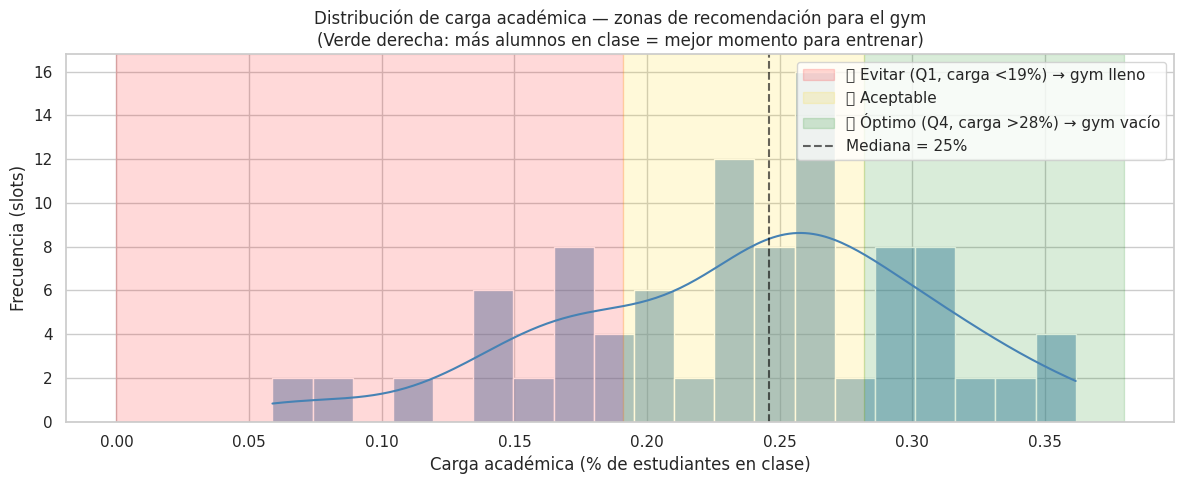


📊 Umbrales de recomendación basados en cuartiles:
🔴 Zona EVITAR:    carga < 19.1% (gym lleno, mucha gente libre)
🟡 Zona aceptable: 19.1% ≤ carga ≤ 28.2%
🟢 Zona ÓPTIMA:    carga > 28.2% (gym vacío, mayoría en clase)


In [98]:
# Cuartiles sobre carga_academica (no sobre ratio_libres)
q25 = agg_op['carga_academica'].quantile(0.25)
q50 = agg_op['carga_academica'].quantile(0.50)
q75 = agg_op['carga_academica'].quantile(0.75)

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(agg_op['carga_academica'], bins=20, kde=True,
             color='steelblue', edgecolor='white', ax=ax)

# Zonas invertidas: izquierda roja (baja carga = gym lleno), derecha verde (alta carga = gym vacío)
ax.axvspan(0, q25, alpha=0.15, color='red',
           label=f'🔴 Evitar (Q1, carga <{q25:.0%}) → gym lleno')
ax.axvspan(q25, q75, alpha=0.15, color='gold',
           label='🟡 Aceptable')
ax.axvspan(q75, agg_op['carga_academica'].max() * 1.05, alpha=0.15, color='green',
           label=f'🟢 Óptimo (Q4, carga >{q75:.0%}) → gym vacío')

ax.axvline(q50, color='black', linestyle='--', alpha=0.6,
           label=f'Mediana = {q50:.0%}')

ax.set_title('Distribución de carga académica — zonas de recomendación para el gym\n(Verde derecha: más alumnos en clase = mejor momento para entrenar)',
             fontsize=12)
ax.set_xlabel('Carga académica (% de estudiantes en clase)')
ax.set_ylabel('Frecuencia (slots)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\n📊 Umbrales de recomendación basados en cuartiles:")
print(f"🔴 Zona EVITAR:    carga < {q25:.1%} (gym lleno, mucha gente libre)")
print(f"🟡 Zona aceptable: {q25:.1%} ≤ carga ≤ {q75:.1%}")
print(f"🟢 Zona ÓPTIMA:    carga > {q75:.1%} (gym vacío, mayoría en clase)")